In [24]:
from sdv.datasets.local import load_csvs
from sdv.metadata import Metadata
from sdv.single_table import CTGANSynthesizer
from sdv.evaluation.single_table import evaluate_quality

## Use SDV to generate synthetic data fro a single tabular dataset

In [25]:
# Load one csv file in `real_data` directory
data = load_csvs(folder_name='real_data')

/home/luzhenna/miniconda3/envs/synth/lib/python3.12/site-packages/sdv/datasets/local.py:36: UserWarning: Ignoring incompatible files ['sdv_demo_fake_hotel_guests_dataset.csv:6E53BFF5-0001-412b-8407-E3AEDE763511'] in folder 'real_data'.
  warnings.warn(f"Ignoring incompatible files {other_files} in folder '{folder_name}'.")


In [26]:
# auto-detect metadata
# metadata = Metadata.detect_from_dataframes(data)
# load metadata from file
metadata = Metadata.load_from_json('metadata_fake_hotel_guests.json')

In [27]:
# preview real data 
data['sdv_demo_fake_hotel_guests_dataset'].head(3)

,index,name,age,guest_email,has_rewards,room_type,amenities_fee,checkin_date,checkout_date,room_rate,billing_address,credit_card_number
0,1,Wang Bin,30,michaelsanders@shaw.net,False,BASIC,37.89,27-Dec-20,29-Dec-20,131.23,"49380 Rivers Street\nSpencerville, AK 68265",4.075085e+18
1,2,Sharma Manish,23,randy49@brown.biz,False,BASIC,24.37,30-Dec-20,2-Jan-21,114.43,"88394 Boyle Meadows\nConleyberg, TN 22063",1.800730e+14
2,3,Avery Scott,42,webermelissa@neal.com,True,DELUXE,0.00,17-Sep-20,18-Sep-20,368.33,"0323 Lisa Station Apt. 208\nPort Thomas, LA 82585",3.898350e+13


In [28]:
synthesizer = CTGANSynthesizer(
    metadata,
    enforce_rounding=False,
    epochs=500,
    verbose=True
)

Add constraints so that `check_out_dates` are always later than `check_in_dates`.

In [29]:
positive_constraint = {
    'constraint_class': 'Positive',
    'constraint_parameters': {
        'column_name': 'room_rate',
        'strict_boundaries': True
    }
}

In [30]:
age_constraint = {
    'constraint_class': 'ScalarRange',
    'constraint_parameters': {
        'column_name': 'age',
        'low_value': 18,
        'high_value': 60,
        'strict_boundaries': True
    }
}

In [31]:
date_constraint ={
    'constraint_class': 'Inequality',
    'constraint_parameters': {
        'low_column_name': 'checkin_date',
        'high_column_name': 'checkout_date',
        'strict_boundaries': True
    }
}

In [32]:
synthesizer.add_constraints(
    constraints=[date_constraint, age_constraint, positive_constraint],
)

In [33]:
data['sdv_demo_fake_hotel_guests_dataset']

,index,name,age,guest_email,has_rewards,room_type,amenities_fee,checkin_date,checkout_date,room_rate,billing_address,credit_card_number
0,1,Wang Bin,30,michaelsanders@shaw.net,False,BASIC,37.89,27-Dec-20,29-Dec-20,131.23,"49380 Rivers Street\nSpencerville, AK 68265",4.075085e+18
1,2,Sharma Manish,23,randy49@brown.biz,False,BASIC,24.37,30-Dec-20,2-Jan-21,114.43,"88394 Boyle Meadows\nConleyberg, TN 22063",1.800730e+14
2,3,Avery Scott,42,webermelissa@neal.com,True,DELUXE,0.00,17-Sep-20,18-Sep-20,368.33,"0323 Lisa Station Apt. 208\nPort Thomas, LA 82585",3.898350e+13
3,4,Daniel Lewis,35,gsims@terry.com,False,BASIC,NaN,28-Dec-20,31-Dec-20,115.61,"77 Massachusetts Ave\nCambridge, MA 02139",4.969552e+15
4,5,Victoria Robinson,28,misty33@smith.biz,False,BASIC,16.45,5-Apr-20,NaN,122.41,"1234 Corporate Drive\nBoston, MA 02116",3.558513e+15
...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,Zhang Hui,39,laurabennett@jones-duncan.net,False,BASIC,8.71,4-Jan-21,6-Jan-21,103.25,"5678 Office Road\nSan Francisco, CA 94103",3.505516e+15
496,497,Patel Akash,33,johnny71@cook.info,False,BASIC,16.31,24-Aug-20,26-Aug-20,115.81,"953 White Island\nChristopherside, TN 91366",2.224525e+15
497,498,Grace Perry,32,ygarcia@ballard-lopez.net,False,BASIC,30.59,11-Nov-20,13-Nov-20,141.61,"5678 Office Road\nSan Francisco, CA 94103",1.800960e+14
498,499,Michael Roberts,34,thomasdale@hall.com,False,BASIC,1.93,16-Jul-20,18-Jul-20,136.92,"5678 Office Road\nSan Francisco, CA 94103",4.488220e+12


In [34]:
synthesizer.fit(data['sdv_demo_fake_hotel_guests_dataset'])


Gen. (-1.09) | Discrim. (-0.16): 100%|██████████| 500/500 [00:37<00:00, 13.26it/s]


In [35]:
synthetic_data = synthesizer.sample(500)

Sampling rows:   0%|          | 0/500 [00:00<?, ?it/s]

Sampling rows: 100%|██████████| 500/500 [00:00<00:00, 648.27it/s]


In [36]:
evaluate_quality(
        data['sdv_demo_fake_hotel_guests_dataset'],
        synthetic_data,
        metadata)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 154.70it/s]|
Column Shapes Score: 82.35%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 223.42it/s]|
Column Pair Trends Score: 84.69%

Overall Score (Average): 83.52%



## Compare data generated by SDV vs. LLM

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load csv file in `real_data` directory
df_real = pd.read_csv('real_data/sdv_demo_fake_hotel_guests_dataset.csv')

In [3]:
# load csv file generated by LLM
df_llm = pd.read_csv('synthetic_output_LLM_sdv_demo_fake_hotel_guests_dataset.csv')

In [4]:
# get the list of columns that are not NaN
not_nan_columns = df_llm.columns[df_llm.notna().any()].tolist()

In [5]:
# load csv file generated by SDV
df_sdv = pd.read_csv('synthetic_data_sdv.csv')

In [6]:
# get a subset of columns that are not NaN in LLM
df_sdv_subset = df_sdv[not_nan_columns]
df_llm_subset = df_llm[not_nan_columns]
df_real_subset = df_real[not_nan_columns]

In [10]:
# subtract checkin_date from checkout_date
# for df_sdv_subset, df_llm_subset, and df_real_subset
df_sdv_subset['stay_duration'] = pd.to_datetime(df_sdv_subset['checkout_date']) - pd.to_datetime(df_sdv_subset['checkin_date'])
df_llm_subset['stay_duration'] = pd.to_datetime(df_llm_subset['checkout_date']) - pd.to_datetime(df_llm_subset['checkin_date'])
df_real_subset['stay_duration'] = pd.to_datetime(df_real_subset['checkout_date']) - pd.to_datetime(df_real_subset['checkin_date'])

/tmp/ipykernel_90382/2935317339.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sdv_subset['stay_duration'] = pd.to_datetime(df_sdv_subset['checkout_date']) - pd.to_datetime(df_sdv_subset['checkin_date'])
/tmp/ipykernel_90382/2935317339.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_llm_subset['stay_duration'] = pd.to_datetime(df_llm_subset['checkout_date']) - pd.to_datetime(df_llm_subset['checkin_date'])
/tmp/ipykernel_90382/2935317339.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expec

/tmp/ipykernel_76818/3368882229.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='room_type', data=df_real_subset, palette='Set2', ax=axs[0])
/tmp/ipykernel_76818/3368882229.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='room_type', data=df_sdv_subset, palette='Set2', ax=axs[1])
/tmp/ipykernel_76818/3368882229.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='room_type', data=df_llm_subset, palette='Set2', ax=axs[2])


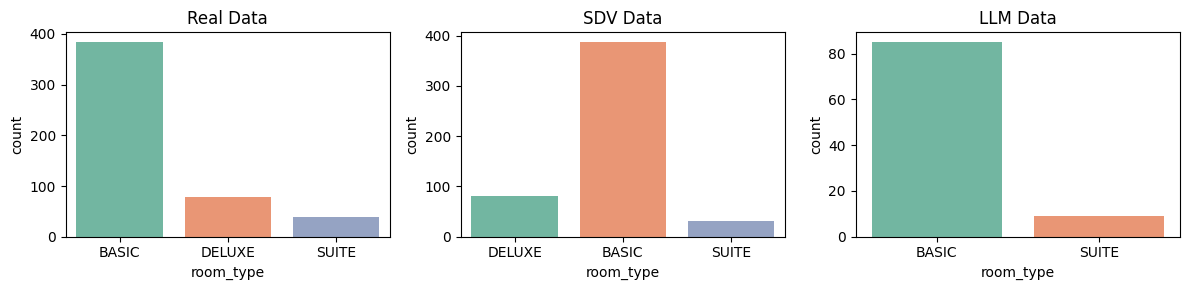

In [29]:
# get a bar plot of room_type in df_real_subset, df_sdv_subset and in df_llm_subset
# arrange in subplots
# arrange x labels
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
sns.countplot(x='room_type', data=df_real_subset, palette='Set2', ax=axs[0])
axs[0].set_title('Real Data')
sns.countplot(x='room_type', data=df_sdv_subset, palette='Set2', ax=axs[1])
axs[1].set_title('SDV Data')
sns.countplot(x='room_type', data=df_llm_subset, palette='Set2', ax=axs[2])
axs[2].set_title('LLM Data')
plt.tight_layout()
plt.show()

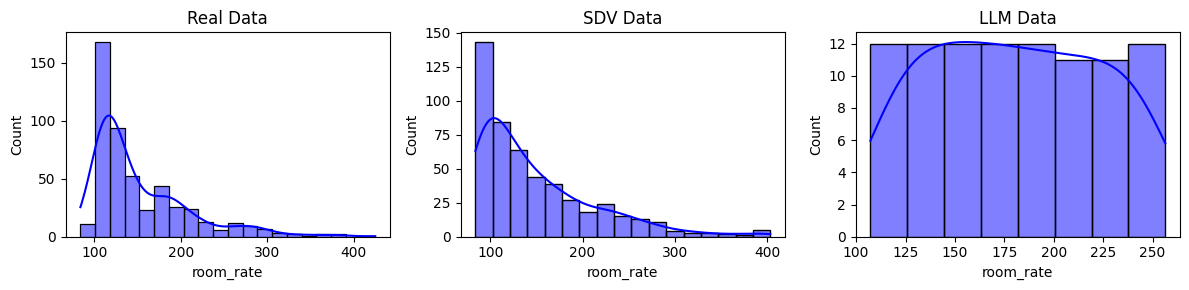

In [30]:
# get a histogram distribution plot of room_rate in df_real_subset, df_sdv_subset and in df_llm_subset
# arrange in subplots
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
sns.histplot(df_real_subset['room_rate'], kde=True, ax=axs[0], color='blue')
axs[0].set_title('Real Data')
sns.histplot(df_sdv_subset['room_rate'], kde=True, ax=axs[1], color='blue')
axs[1].set_title('SDV Data')
sns.histplot(df_llm_subset['room_rate'], kde=True, ax=axs[2], color='blue')
axs[2].set_title('LLM Data')
plt.tight_layout()
plt.show()

correlation between columns

/tmp/ipykernel_76818/1683335870.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='room_type', y='room_rate', data=df_real_subset, palette='Set2', ax=axs[0])
/tmp/ipykernel_76818/1683335870.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='room_type', y='room_rate', data=df_sdv_subset, palette='Set2', ax=axs[1])
/tmp/ipykernel_76818/1683335870.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='room_type', y='room_rate', data=df_llm_subset, palette='Set2', ax=axs[2])


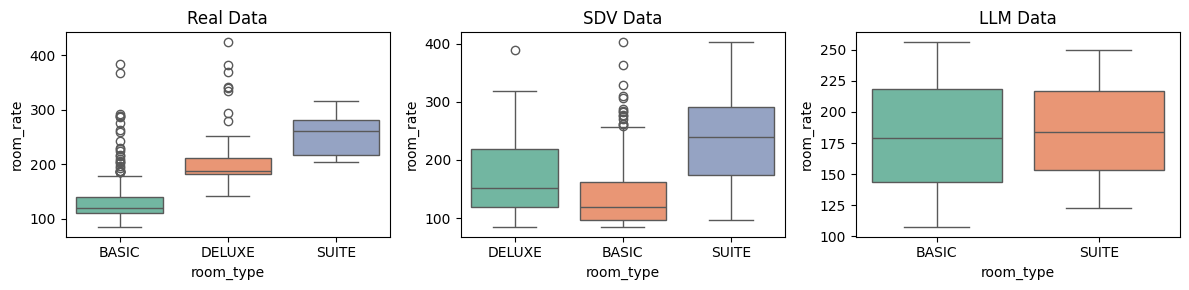

In [32]:
# plot boxplot of room_rate by room_type in df_real_subset, df_sdv_subset and in df_llm_subset
# arrange in subplots
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
sns.boxplot(x='room_type', y='room_rate', data=df_real_subset, palette='Set2', ax=axs[0])
axs[0].set_title('Real Data')
sns.boxplot(x='room_type', y='room_rate', data=df_sdv_subset, palette='Set2', ax=axs[1])
axs[1].set_title('SDV Data')
sns.boxplot(x='room_type', y='room_rate', data=df_llm_subset, palette='Set2', ax=axs[2])
axs[2].set_title('LLM Data')
plt.tight_layout()
plt.show()

/tmp/ipykernel_90382/1777237410.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stay_duration', y='amenities_fee', data=df_real_subset, palette='Set2', ax=axs[0])
/tmp/ipykernel_90382/1777237410.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stay_duration', y='amenities_fee', data=df_sdv_subset, palette='Set2', ax=axs[1])
/tmp/ipykernel_90382/1777237410.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stay_duration', y='amenities_fee', data=df_llm_subset, palette='Set2', ax=axs[2])


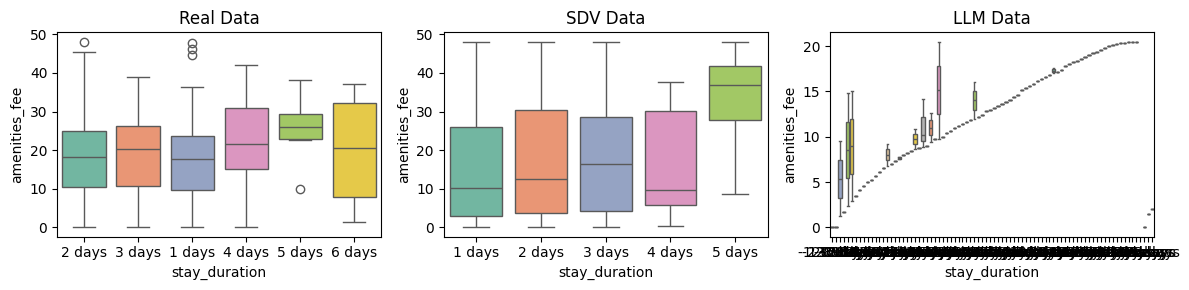

In [18]:
# plot boxplot of amenities_fee by stay_duration in df_real_subset, df_sdv_subset and in df_llm_subset
# arrange in subplots
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
sns.boxplot(x='stay_duration', y='amenities_fee', data=df_real_subset, palette='Set2', ax=axs[0])
axs[0].set_title('Real Data')
sns.boxplot(x='stay_duration', y='amenities_fee', data=df_sdv_subset, palette='Set2', ax=axs[1])   
axs[1].set_title('SDV Data')
sns.boxplot(x='stay_duration', y='amenities_fee', data=df_llm_subset, palette='Set2', ax=axs[2])
axs[2].set_title('LLM Data')
plt.tight_layout()
plt.show()